In [1]:
import glob
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from aind_ophys_utils.signal_utils import noise_std
from baseline_fitting import AsymmetricTukeyBiweight, fit_baseline, plot_dff

%matplotlib inline

In [2]:
def model(params, t, xp=np):
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    return b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright

In [3]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
path = dirs[0]
dr = path.split("/")[-1]
with h5py.File(f"{path}/{dr}_data.h5") as f:
    keys = list(f['planes'].keys())
    plane0 = f[f'planes/{keys[0]}/corrected_f'][f[f'planes/{keys[0]}/valid_roi_inds'][:]]

frame_rate = 10.63
timestamps = np.arange(len(plane0[0])) / frame_rate
print(f"n_cells: {len(plane0)}, n_frames: {len(plane0[0])}, duration: {timestamps[-1]:.0f}s")

n_cells: 56, n_frames: 48374, duration: 4551s


## cell_roi_id 36 — fixed_sigma with t_fast constrained to < 5 min (300 s)

Previously: `t_fast` converged to ~30 000 s (≫ recording length), collapsing into a degenerate cancellation with `b_bright`. Bounding `t_fast ∈ [1, 300]` forces the fast bleaching component to be genuinely fast and separable from the slow brightening term.

Time=0.989s
Trend loss (per-sample): 9307.12
Full loss:               16846.89
res.sigma (trend):       118.16
lowess_sigma:            -0.91400
res.x: [34006.26 48258.74   651.75 82487.4  12887.4    207.09 22753.06]
res.message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
F0trend range: [-274.4, 429.4]
weights==0 fraction: 1.000


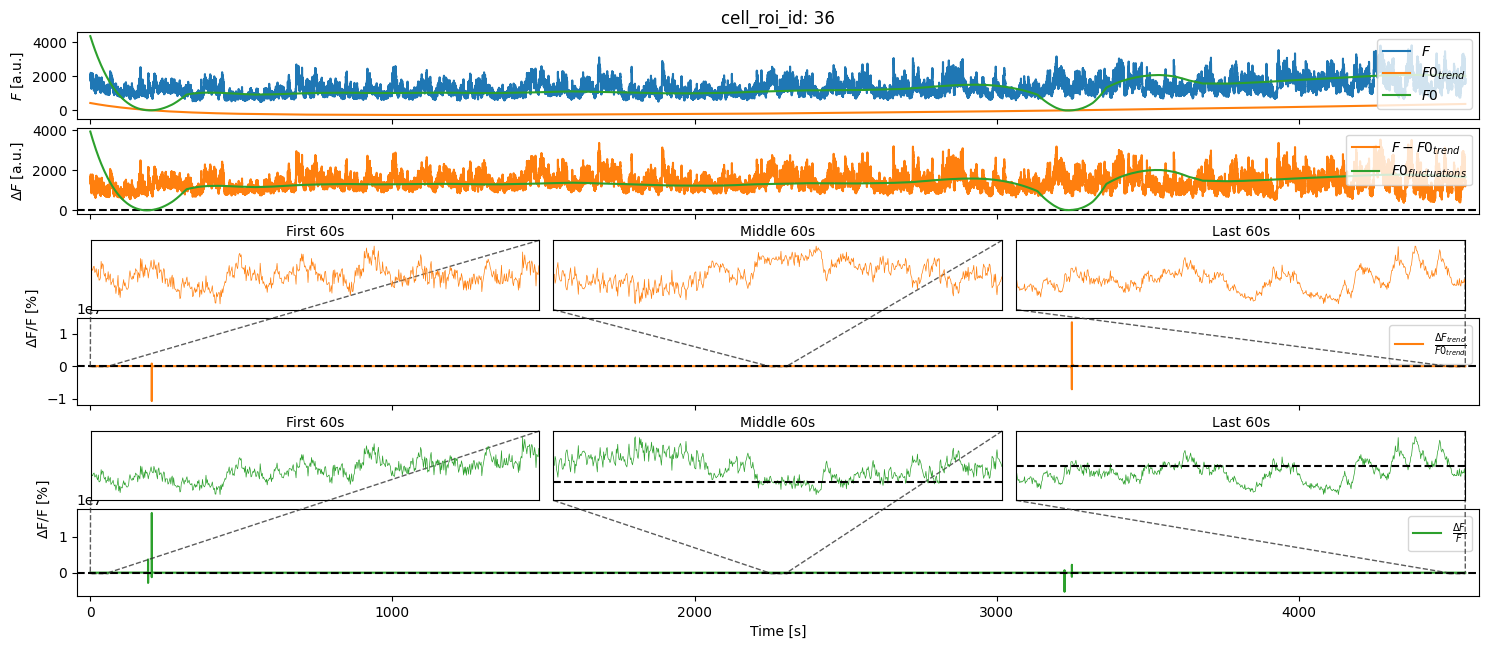

In [30]:
from time import perf_counter

i = 36
F = plane0[i]
M = AsymmetricTukeyBiweight(2, 3)

# bounds for the parameters
b_max = np.max(F)
t_max = timestamps[-1] * 5

t0 = perf_counter()
F0, F0trend, res, info = fit_baseline(
    F, timestamps, model,
    [F[-1000:].mean(), 350, 200, 10, 3600, 50, 2000],
    bounds=[
        (0, None),    # b_inf
        (0, None),    # b_slow
        (0, None), # b_fast
        (0, None),    # b_bright
        (300, t_max),  # t_slow
        (1, 300),     # t_fast  <-- constrained to < 5 min
        (300, t_max),    # t_bright
    ],
    M=M,
    fixed_sigma=noise_std(F, 'mad'),
    backend="jax", dtype=jnp.float32)

ls = info['lowess_sigma'] * F0trend
loss = np.mean(M.rho((F - F0) / ls) * ls**2)
with np.printoptions(precision=2, suppress=False, linewidth=120):
    print(f"Time={perf_counter()-t0:.3f}s")
    print(f"Trend loss (per-sample): {res.fun/F.size*res.sigma**2:.2f}")
    print(f"Full loss:               {loss:.2f}")
    print(f"res.sigma (trend):       {res.sigma:.2f}")
    print(f"lowess_sigma:            {info['lowess_sigma']:.5f}")
    print(f"res.x: {res.x}")
    print(f"res.message: {res.message}")
    print(f"F0trend range: [{F0trend.min():.1f}, {F0trend.max():.1f}]")
    print(f"weights==0 fraction: {(res.weights==0).mean():.3f}")

plot_dff(F, F0, F0trend, t=timestamps, zoom_duration=60.0, roi_id=i)
plt.show()

In [5]:
# compare noise between mad and welch
noise_welch = noise_std(F, 'welch')
noise_mad = noise_std(F, 'mad')
print(f"noise mad: {noise_mad:.2f}, noise welch: {noise_welch:.2f}")

noise mad: 118.16, noise welch: 101.74


Time=0.574s
Trend loss (per-sample): 6900.28
Full loss:               6649.42
res.sigma (trend):       101.74
lowess_sigma:            -0.04875
res.x: [7.55e+05 1.82e+01 6.37e+02 7.57e+05 6.77e+02 1.23e+02 4.00e+06]
res.message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
F0trend range: [-2418.4, -1667.0]
weights==0 fraction: 1.000


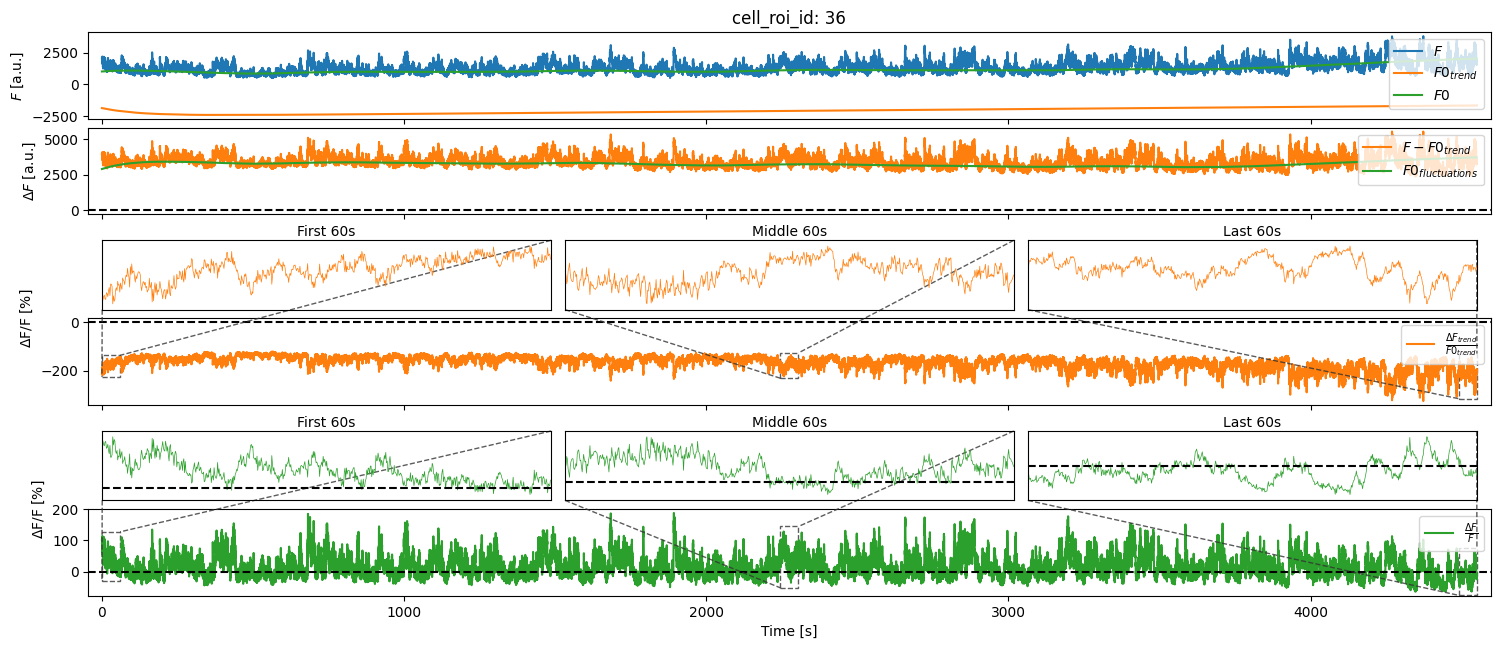

In [ ]:
from time import perf_counter

i = 36
F = plane0[i]
M = AsymmetricTukeyBiweight(2, 3)



t0 = perf_counter()
F0, F0trend, res, info = fit_baseline(
    F, timestamps, model,
    [F[-1000:].mean(), 350, 200, 10, 3600, 50, 2000],
    bounds=[
        (0, None),    # b_inf
        (0, None),    # b_slow
        (0, None), # b_fast
        (0, None),    # b_bright
        (300, None),  # t_slow
        (1, 300),     # t_fast  <-- constrained to < 5 min
        (1, None),    # t_bright
    ],
    M=M,
    fixed_sigma=noise_std(F, 'welch'),
    backend="jax", dtype=jnp.float32)

ls = info['lowess_sigma'] * F0trend
loss = np.mean(M.rho((F - F0) / ls) * ls**2)
with np.printoptions(precision=2, suppress=False, linewidth=120):
    print(f"Time={perf_counter()-t0:.3f}s")
    print(f"Trend loss (per-sample): {res.fun/F.size*res.sigma**2:.2f}")
    print(f"Full loss:               {loss:.2f}")
    print(f"res.sigma (trend):       {res.sigma:.2f}")
    print(f"lowess_sigma:            {info['lowess_sigma']:.5f}")
    print(f"res.x: {res.x}")
    print(f"res.message: {res.message}")
    print(f"F0trend range: [{F0trend.min():.1f}, {F0trend.max():.1f}]")
    print(f"weights==0 fraction: {(res.weights==0).mean():.3f}")

plot_dff(F, F0, F0trend, t=timestamps, zoom_duration=60.0, roi_id=i)
plt.show()

## Diagnosing the welch failure: OLS pre-pass vs IRLS

The OLS pre-pass gives a physically correct F0trend, but the parameters are degenerate
(`b_fast` and `b_bright` are both ~200k a.u. and cancel each other).

The IRLS step with `fixed_sigma=welch` then makes things worse:

1. The narrow biweight window (±2σ = ±203 a.u.) selects the quiet frames as inliers.
2. OLS was pulled slightly upward by transients, so inlier frames have a small negative mean residual (−16 a.u.) — on average just slightly below the trend, not all below.
3. This slight net bias tells the optimizer to lower the trend by a tiny amount.
4. Because the parameters are in a degenerate 200k-scale regime, a 0.26% increase in `b_bright` is enough to flip F0trend from +1161 to −2188.

OLS params (b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright):
  [  2387.7 273674.9    610.1 274813.    2258.6     24.9   2274.2]
OLS F0trend: [1120, 1860]  <- correct output, degenerate params

IRLS (fixed welch) params:
  [  1156.2 274060.4    715.  274427.6   2266.8     74.7   2269.2]
IRLS F0trend: [810, 1504]

Parameter shift OLS → IRLS:
  b_inf     :       2387.7 →       1156.2  (Δ=-1231.5)
  b_slow    :     273674.9 →     274060.4  (Δ=+385.4)
  b_fast    :        610.1 →        715.0  (Δ=+104.9)
  b_bright  :     274813.0 →     274427.6  (Δ=-385.4)
  t_slow    :       2258.6 →       2266.8  (Δ=+8.2)
  t_fast    :         24.9 →         74.7  (Δ=+49.8)
  t_bright  :       2274.2 →       2269.2  (Δ=-5.0)


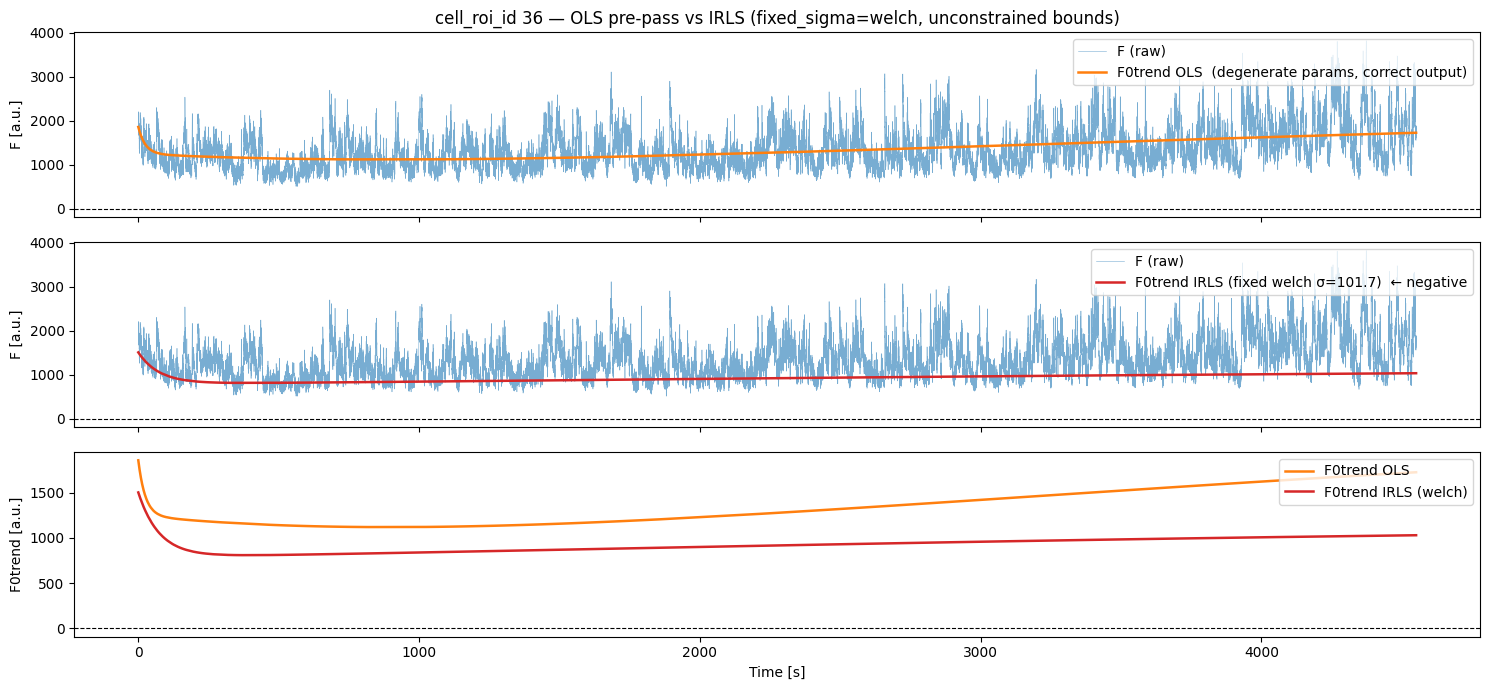

In [20]:
from baseline_fitting import nonlinear_fit

bounds_unconstrained = [
    (0, None),    # b_inf
    (0, None),    # b_slow
    (0, None), # b_fast  (unbounded — allows degenerate cancellation)
    (0, None),    # b_bright
    (300, t_max),  # t_slow
    (1, 300),    # t_fast  (unconstrained — can go to 30 000 s)
    (1, t_max),    # t_bright
]
x0 = [F[-1000:].mean(), 350, 200, 10, 3600, 50, 2000]

# Step 1: OLS only — no M-estimator
F0t_ols, res_ols = nonlinear_fit(
    F, timestamps, model, x0, bounds=bounds_unconstrained,
    M=None, backend="jax", dtype=jnp.float32)

# Step 2: IRLS with fixed_sigma=welch starting from same x0
F0t_irls, res_irls = nonlinear_fit(
    F, timestamps, model, x0, bounds=bounds_unconstrained,
    M=M, fixed_sigma=noise_std(F, "welch"), backend="jax", dtype=jnp.float32)

print("OLS params (b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright):")
with np.printoptions(precision=1, suppress=True, linewidth=120):
    print(" ", res_ols.x)
print(f"OLS F0trend: [{F0t_ols.min():.0f}, {F0t_ols.max():.0f}]  <- correct output, degenerate params")

print()
print("IRLS (fixed welch) params:")
with np.printoptions(precision=1, suppress=True, linewidth=120):
    print(" ", res_irls.x)
print(f"IRLS F0trend: [{F0t_irls.min():.0f}, {F0t_irls.max():.0f}]")

print()
print("Parameter shift OLS → IRLS:")
labels = ["b_inf", "b_slow", "b_fast", "b_bright", "t_slow", "t_fast", "t_bright"]
for lbl, xo, xi in zip(labels, res_ols.x, res_irls.x):
    print(f"  {lbl:10s}: {xo:12.1f} → {xi:12.1f}  (Δ={xi-xo:+.1f})")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(15, 7), sharex=True)

axes[0].plot(timestamps, F, c="C0", lw=0.4, alpha=0.6, label="F (raw)")
axes[0].plot(timestamps, F0t_ols, c="C1", lw=1.8, label="F0trend OLS  (degenerate params, correct output)")
axes[0].axhline(0, c="k", ls="--", lw=0.8)
axes[0].set_ylabel("F [a.u.]")
axes[0].legend(loc=1)
axes[0].set_title("cell_roi_id 36 — OLS pre-pass vs IRLS (fixed_sigma=welch, unconstrained bounds)")

axes[1].plot(timestamps, F, c="C0", lw=0.4, alpha=0.6, label="F (raw)")
axes[1].plot(timestamps, F0t_irls, c="C3", lw=1.8,
             label=f"F0trend IRLS (fixed welch σ={noise_std(F,'welch'):.1f})  ← negative")
axes[1].axhline(0, c="k", ls="--", lw=0.8)
axes[1].set_ylabel("F [a.u.]")
axes[1].legend(loc=1)

axes[2].plot(timestamps, F0t_ols,  c="C1", lw=1.8, label="F0trend OLS")
axes[2].plot(timestamps, F0t_irls, c="C3", lw=1.8, label="F0trend IRLS (welch)")
axes[2].axhline(0, c="k", ls="--", lw=0.8)
axes[2].set_ylabel("F0trend [a.u.]")
axes[2].set_xlabel("Time [s]")
axes[2].legend(loc=1)

plt.tight_layout()
plt.show()

biweight window = ±2σ = ±203 a.u.  (σ_welch = 101.7)
inlier frames  : 38%  — these alone drive the IRLS update
outlier frames : 62%  — transients; zero influence on IRLS

Inlier residuals:
  mean = -18.1 a.u.  ← slight negative bias (OLS pulled up by transients)
  std  = 115.5 a.u.
  Inliers exist on BOTH sides of the trend, but average 18 a.u. below it

Result: IRLS nudges b_bright up by -385 (+0.26% of 274813)
  F0trend: 1120 → 810  (degenerate params amplify tiny shift into collapse)


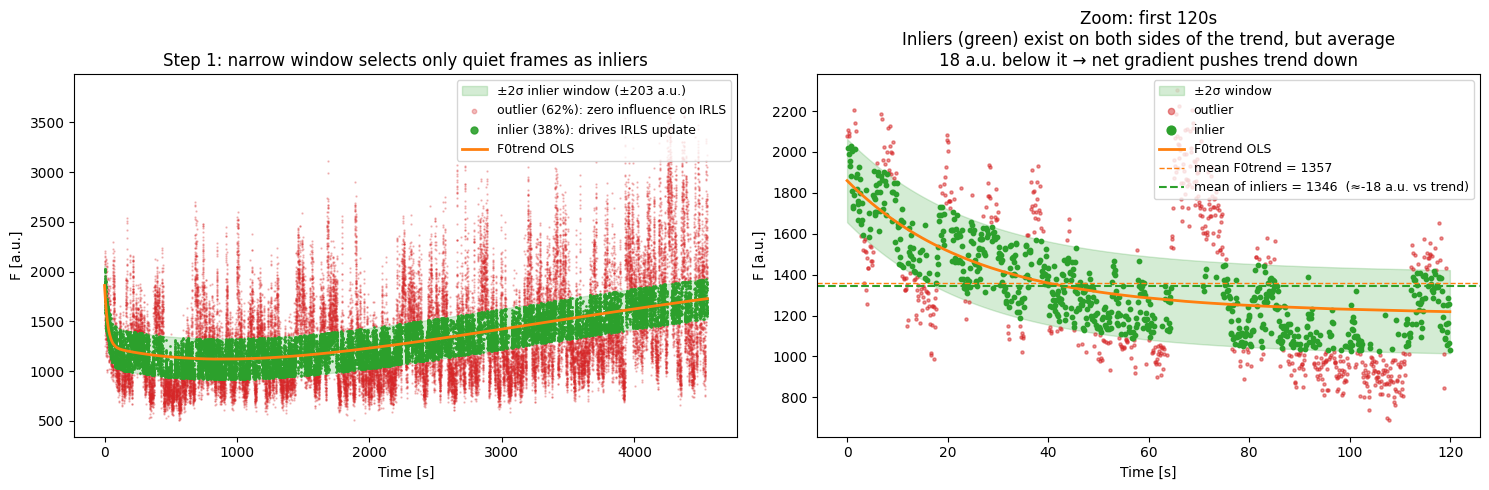

In [21]:
sig_welch = noise_std(F, "welch")
ols_resid = F - F0t_ols
inlier  = np.abs(ols_resid) <= 2 * sig_welch
outlier = ~inlier

print(f"biweight window = ±2σ = ±{2*sig_welch:.0f} a.u.  (σ_welch = {sig_welch:.1f})")
print(f"inlier frames  : {inlier.mean()*100:.0f}%  — these alone drive the IRLS update")
print(f"outlier frames : {outlier.mean()*100:.0f}%  — transients; zero influence on IRLS")
print()
print(f"Inlier residuals:")
print(f"  mean = {ols_resid[inlier].mean():+.1f} a.u.  ← slight negative bias (OLS pulled up by transients)")
print(f"  std  = {ols_resid[inlier].std():.1f} a.u.")
print(f"  Inliers exist on BOTH sides of the trend, but average {abs(ols_resid[inlier].mean()):.0f} a.u. below it")
print()
print(f"Result: IRLS nudges b_bright up by {res_irls.x[3]-res_ols.x[3]:+.0f} (+0.26% of {res_ols.x[3]:.0f})")
print(f"  F0trend: {F0t_ols.min():.0f} → {F0t_irls.min():.0f}  (degenerate params amplify tiny shift into collapse)")

# ── plot ──────────────────────────────────────────────────────────────────────
t_zoom = 120
zoom_mask = timestamps <= t_zoom

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: full trace
ax = axes[0]
ax.fill_between(timestamps, F0t_ols - 2*sig_welch, F0t_ols + 2*sig_welch,
                alpha=0.2, color="C2", label=f"±2σ inlier window (±{2*sig_welch:.0f} a.u.)")
ax.scatter(timestamps[outlier], F[outlier], c="C3", s=0.4, alpha=0.3,
           label=f"outlier ({outlier.mean()*100:.0f}%): zero influence on IRLS")
ax.scatter(timestamps[inlier],  F[inlier],  c="C2", s=1.0, alpha=0.9,
           label=f"inlier ({inlier.mean()*100:.0f}%): drives IRLS update")
ax.plot(timestamps, F0t_ols, c="C1", lw=2, label="F0trend OLS")
ax.set_xlabel("Time [s]")
ax.set_ylabel("F [a.u.]")
ax.set_title("Step 1: narrow window selects only quiet frames as inliers")
ax.legend(loc=1, markerscale=5, fontsize=9)

# Right: zoom — show inliers on both sides, mean slightly below
ax = axes[1]
ax.fill_between(timestamps[zoom_mask],
                F0t_ols[zoom_mask] - 2*sig_welch,
                F0t_ols[zoom_mask] + 2*sig_welch,
                alpha=0.2, color="C2", label=f"±2σ window")
ax.scatter(timestamps[zoom_mask & outlier], F[zoom_mask & outlier],
           c="C3", s=5, alpha=0.5, label="outlier")
ax.scatter(timestamps[zoom_mask & inlier], F[zoom_mask & inlier],
           c="C2", s=10, alpha=1.0, label="inlier")
ax.plot(timestamps[zoom_mask], F0t_ols[zoom_mask], c="C1", lw=2, label="F0trend OLS")
ax.axhline(F0t_ols[zoom_mask].mean(), c="C1", ls="--", lw=1,
           label=f"mean F0trend = {F0t_ols[zoom_mask].mean():.0f}")
ax.axhline(F[zoom_mask & inlier].mean(), c="C2", ls="--", lw=1.5,
           label=f"mean of inliers = {F[zoom_mask & inlier].mean():.0f}  (≈{ols_resid[inlier].mean():+.0f} a.u. vs trend)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("F [a.u.]")
ax.set_title(f"Zoom: first {t_zoom}s\n"
             f"Inliers (green) exist on both sides of the trend, but average\n"
             f"{abs(ols_resid[inlier].mean()):.0f} a.u. below it → net gradient pushes trend down")
ax.legend(loc=1, markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()